In [1]:
%reload_ext autoreload
%autoreload 2
# %matplotlib qt
%matplotlib inline

import torch
from matplotlib import pyplot as plt

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import save_figure
from dimensionality_manuscript.registry import PopulationRegistry, RegistryPaths
from dimensionality_manuscript import SubspaceConfig, StimSpaceSpectraConfig, CVPCAConfig, TilburyFitConfig
from dimensionality_manuscript import ResultsAggregator, ResultsStore, get_data_config 
plt.rcParams["font.size"] = 14

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
registry = PopulationRegistry(registry_params=get_data_config("even").to_registry_params())
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure4"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [2]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()
cfg = StimSpaceSpectraConfig()
results = ResultsAggregator(cfg, store, sessions)

cfg_cvpca = CVPCAConfig()
results_cvpca = ResultsAggregator(cfg_cvpca, store, sessions)

cfg_fit = TilburyFitConfig()
results_fit = ResultsAggregator(cfg_fit, store, sessions)

cfg_subspace = SubspaceConfig()
results_subspace = ResultsAggregator(cfg_subspace, store, sessions)

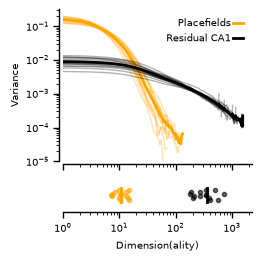

In [11]:
from dimensionality_manuscript.figure_scripts.figure4 import SpectrumFigureViewer

show_viewer = False
viewer = SpectrumFigureViewer(
    results,
    results_cvpca=results_cvpca,
    results_subspace=results_subspace,
    results_fit=results_fit,
    ylim_min=-5.0,
    ylim_max=-0.5,
    source_key = "ss_cvpca",
    source_mode = "all",
    full_source_key = "SVCA_RES",
    activity_parameters_name="std",
    smooth_widths=(5.0, None),
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    normalize=True,
    pr_pre_smooth=True,
    clip_negative=True,
    figsize=(2.5, 2.5),
    fontsize=7,
)

if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "main_spectra_curves")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import DimensionalityFamiliarityViewer, AdaptiveAlphaConfig

source_cfg = AdaptiveAlphaConfig(
    smooth_method="gaussian",
    smooth_width=3.0,
    fpd_window_size=1,
    adaptive_buffer=2,
    minimum_window_size=10,
)
full_cfg = AdaptiveAlphaConfig(
    smooth_method="gaussian",
    smooth_width=20.0,
    fpd_window_size=20,
    adaptive_buffer=10,
    minimum_window_size=100,
)

viewer = DimensionalityFamiliarityViewer(
    results,
    results_cvpca=results_cvpca,
    results_subspace=results_subspace,
    source_key = "ss_cvpca",
    full_key = "SVCA_RES",
    full_scope = "full1",
    plot_mode="by_env",
    clip_negative=True,
    pr_pre_smooth=True,
    metric="participation_ratio",
    k_method="hardcode",
    k_value=20,
    log_y=True,
    ylim_start_at_one=True,
    sharey=True,
    source_cfg=source_cfg,
    full_cfg=full_cfg,
    activity_parameters_name="std",
    smooth_widths=(5.0, None),
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    pf_text_y=0.08,
    ff_text_y=0.08,
    figsize=(4.5, 2.0),
    legend_options=dict(
        loc="upper left",
    ),
    fontsize=7,
)

show_viewer = True
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "dimensionality_by_session")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import SpectrumCurvesByFamiliarityViewer

show_viewer = True
viewer = SpectrumCurvesByFamiliarityViewer(
    results,
    results_cvpca=results_cvpca,
    results_subspace=results_subspace,
    source_key = "ss_cvpca",
    full_key = "SVCA_RES",
    full_scope = "full1",
    plot_mode="avg_env",
    log_x=True,
    log_y=True,
    clip_negative=True,
    activity_parameters_name="std",
    smooth_widths=(5.0, None),
    reliability_fraction_active_thresholds=(None, None),
    include_iti=False,
    figsize=(7.0, 3.0),
    fontsize=7,
)

if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "spectra_curves_by_familiarity")

In [3]:
# from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldSpectraViewer

# viewer = PlacefieldSpectraViewer(
#     results,
#     results_cvpca=results_cvpca,
#     ylim_min=-6.5,
#     fontsize=9,
#     figsize=(12, 4),
#     activity_parameters_name="default",
#     fit_range=(20, 30),
#     smooth_widths=(5.0, None),
#     smooth_kind="gaussian",
#     smooth_width=3.0,
#     reliability_fraction_active_thresholds=(None, None),
#     include_iti=False,
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = False
# #     if save:
# #         save_figure(fig, figure_path / "placefield_spectra")


In [ ]:
# from dimensionality_manuscript.figure_scripts.figure4 import SessionSpectraViewer

# viewer = SessionSpectraViewer(
#     results,
#     results_cvpca=results_cvpca,
#     fit_range=(15, 30),
#     ylim_min=-6.5,
#     fontsize=9,
#     figsize=(12, 4),
#     activity_parameters_name="default",
#     smooth_widths=(None, None),
#     reliability_fraction_active_thresholds=(None, None),
#     include_iti=False,
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = False
# #     if save:
# #         save_figure(fig, figure_path / "placefield_spectra")


In [ ]:
# from dimensionality_manuscript.figure_scripts.figure4 import SpectrumDimFamiliarityViewer

# viewer = SpectrumDimFamiliarityViewer(
#     results,
#     results_subspace=results_subspace,
#     source_key = "ss_cvpca",
#     activity_parameters_name="default",
#     smooth_widths=(5.0, None),
#     reliability_fraction_active_thresholds=(None, None),
#     include_iti=False,
#     figsize=(4.5, 2.5),
#     fontsize=7,
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = False
# #     if save:
# #         save_figure(fig, figure_path / "dimensionality_by_environment")


In [ ]:
# from dimensionality_manuscript.figure_scripts.figure4 import AdaptiveSpectraEstimationViewer

# viewer = AdaptiveSpectraEstimationViewer(
#     results,
#     results_cvpca=results_cvpca,
#     results_subspace=results_subspace,
#     ylim_min=-5.5,
#     fontsize=9,
#     key = "ss_cvpca",
#     activity_parameters_name="default",
#     fit_range=(20, 30),
#     smooth_widths=(5.0, None),
#     smooth_kind="gaussian",
#     smooth_width=3.0,
#     adaptive_buffer=2,
#     reliability_fraction_active_thresholds=(None, None),
#     include_iti=False,
#     normalize=False,
#     figsize=(12.0, 3.0),
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = True
# #     if save:
# #         save_figure(fig, figure_path / "adaptive_spectra_example")


In [ ]:
# from IPython.display import clear_output
# from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldExampleFitViewer

# session_targets = {
#     "ATL012": ["2023-03-03"],
#     # "ATL020": ["2023-03-31", "2023-04-04", "2023-04-05", "2023-04-06"],
#     # "ATL022": ["2023-04-12", "2023-04-19"],
#     # "ATL027": ["2023-07-21"],
#     # "ATL049": ["2024-04-30"],
#     # "ATL057": ["2024-07-16", "2024-07-19"],
# }

# for isession, session in tqdm(enumerate(sessions)):
#     if session.mouse_name not in session_targets:
#         # print(f"Skipping session {session.session_uid} because mouse {session.mouse_name} is not in session_targets.")
#         continue
#     if session.date not in session_targets[session.mouse_name]:
#         # print(f"Skipping session {session.session_uid} because date {session.date} is not in session_targets for mouse {session.mouse_name}.")
#         continue

#     try:
#         viewer = PlacefieldExampleFitViewer(
#             results_fit,
#             registry,
#             example_session = session.session_uid,
#             n_rows = 5,
#             n_cols = 3,
#             r2_threshold = 0.65,
#             improvement_threshold = 0.01,
#             normalize="std",
#             normalize_independent=True,
#             random_seed=2,
#             figsize = (12.0, 7.5),
#             fontsize = 9.0,
#         )
#         fig = viewer.plot(viewer.state)
#     except Exception as e:
#         print(f"Error occurred while processing session {session.session_uid}: {e}")
#     fig.suptitle(f"Session {session.session_uid}", fontsize=12)
#     plt.show()

#     save = True
#     if save:
#         path_name = f"placefield_fits_{session.session_uid}"
#         save_figure(fig, figure_path / "fit_examples" / path_name)




In [ ]:
# from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldFitFigureViewer

# neuron_list = [
#     ("ATL012.2023-03-03.701", 5378),
#     ("ATL012.2023-03-03.701", 3672), # keep
#     ("ATL020.2023-03-31.701", 11785),
#     ("ATL020.2023-04-05.701", 11623), # keep
#     ("ATL020.2023-04-05.701", 11040),
#     ("ATL020.2023-04-06.701", 10540),
#     ("ATL022.2023-04-12.701", 5515),
#     ("ATL022.2023-04-19.701", 7334),
#     ("ATL022.2023-04-19.701", 751),
#     ("ATL027.2023-07-21.701", 1849), #keep
#     ("ATL027.2023-07-21.701", 2513),
#     ("ATL057.2024-07-16.701", 6434),
#     # ("ATL057.2024-07-19.701", 6149),
# ]

# session_uids, neurons = zip(*neuron_list)

# viewer = PlacefieldFitFigureViewer(
#     results_fit,
#     registry,
#     session_uids=session_uids,
#     neurons=neurons,
#     n_rows=3,
#     n_cols=4,
#     normalize="std",
#     normalize_independent=True,
#     figsize=(12.0, 6.0),
#     fontsize=9.0,
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = False
# #     if save:
# #         save_figure(fig, figure_path / "placefield_fit_many_examples")




In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldFitFigureViewer

best_neuron_list = [
    ("ATL012.2023-03-03.701", 3672), # keep
    ("ATL027.2023-07-21.701", 1849), #keep
    ("ATL020.2023-04-05.701", 11623), # keep
]

session_uids, neurons = zip(*best_neuron_list)

viewer = PlacefieldFitFigureViewer(
    results_fit,
    registry,
    session_uids=session_uids,
    neurons=neurons,
    n_rows=1,
    n_cols=3,
    fit_model="shrinkage",
    normalize="std",
    normalize_independent=True,
    legend_x_offset = 0.2,
    legend_handlelength=1.2,
    legend_handletextpad=0.8,
    figsize=(4.45, 1.5),
    fontsize=8.0,
)

# static path (matches the original notebook's live behavior for this cell):
fig = viewer.plot(viewer.state)
plt.show()

save = True
if save:
    save_figure(fig, figure_path / "placefield_fit_best_examples")

# or, for the interactive viewer:
# viewer.show()


In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldPopulationViewer

source_cfg = AdaptiveAlphaConfig(
    smooth_method="gaussian",
    smooth_width=3.0,
    fpd_window_size=1,
    adaptive_buffer=2,
    minimum_window_size=10,
)

viewer = PlacefieldPopulationViewer(
    results_fit,
    results_spectra=results,
    results_cvpca=results_cvpca,
    reliability_fraction_active_thresholds=(0.3, 0.1),
    smooth_widths=(5.0, None),
    source_key="ss_cvpca",
    metric="r2",
    generalized_fit="shrinkage",
    include_better=False,
    num_bins = 80,
    fraction_view = "none",
    normalize=False,
    beewidth = 0.2,
    source_cfg=source_cfg,
    last_axis="characteristic_dim",
    display="errorPlot",
    legend=dict(
        loc="upper left",
        handlelength=1.0,
        handletextpad=0.7,
        labelspacing=0.25,
        borderpad=0.1,
        borderaxespad=0.5,
    ),
    fontsize = 8.0,
    figsize = (4.45, 1.9),
)

# static path (matches the original notebook's live behavior for this cell):
fig = viewer.plot(viewer.state)
plt.show()

save = True
if save:
    save_figure(fig, figure_path / "placefield_fit_stats")

# or, for the interactive viewer:
# viewer.show()



In [ ]:
# from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldParameterSessionsViewer

# viewer = PlacefieldParameterSessionsViewer(
#     results_fit,
#     num_bins = 80,
#     fit="shrinkage",
#     display="errorPlot",
#     fontsize = 8.0,
#     figsize = (5.0, 3.0),
# )
# viewer.show()

# # or: fig = viewer.plot(viewer.state); plt.show()
# #     save = True
# #     if save:
# #         save_figure(fig, figure_path / "placefield_fit_stats_familiarity")



In [ ]:
from dimensionality_manuscript.figure_scripts.figure4 import PlacefieldSpectrumMSEViewer

source_cfg = AdaptiveAlphaConfig(
    smooth_method="gaussian",
    smooth_width=3.0,
    fpd_window_size=1,
    adaptive_buffer=2,
    minimum_window_size=10,
)

viewer = PlacefieldSpectrumMSEViewer(
    results_fit,
    results_spectra=results,
    results_cvpca=results_cvpca,
    reliability_fraction_active_thresholds=(0.3, 0.1),
    smooth_widths=(5.0, None),
    source_key="ss_cvpca",
    generalized_fit="shrinkage",
    display="errorPlot",
    normalize=False,
    source_cfg=source_cfg,
    fontsize = 9.0,
    figsize = (7.0, 2.5),
)
viewer.show()

# or, for the static figure:
# fig = viewer.plot(viewer.state)
# plt.show()

# save = True
# if save:
#     save_figure(fig, figure_path / "placefield_spectrum_mse")

